In [ ]:
# !nvidia-smi

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"   # 只让第3块物理卡可见
# os.environ["CUDA_VISIBLE_DEVICES"] = "3,5"  # 让第4和第6块卡可见（多卡）
import numpy as np
import torch, faiss

# 现在进程里，"cuda:0" 就是物理 GPU-2；"cuda:1" 就是物理 GPU-5
device = torch.device("cuda:0")
torch.cuda.set_device(device)

print("torch 可见卡数:", torch.cuda.device_count())
print("当前卡:", torch.cuda.current_device(), torch.cuda.get_device_name())
print("FAISS 可见 GPU 数:", faiss.get_num_gpus())


torch 可见卡数: 1
当前卡: 0 NVIDIA GeForce RTX 3090
FAISS 可见 GPU 数: 1


In [3]:
import os
import torch
import pandas as pd
import pyterrier as pt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Initialize PyTerrier
if not pt.started():
    pt.init()


/tmp/ipykernel_3785850/896768055.py:9: DeprecationWarning: Call to deprecated function (or staticmethod) started. (use pt.java.started() instead) -- Deprecated since version 0.11.0.
  if not pt.started():
Java started and loaded: pyterrier.java, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]
/tmp/ipykernel_3785850/896768055.py:10: DeprecationWarning: Call to deprecated method pt.init(). Deprecated since version 0.11.0.
java is now started automatically with default settings. To force initialisation early, run:
pt.java.init() # optional, forces java initialisation
  pt.init()


In [4]:
# Step 1: Load dataset
dataset = pt.get_dataset("msmarco_passage")
topics19 = dataset.get_topics("test-2019")
qrels2019 = dataset.get_qrels("test-2019")
topics2019 = topics19.merge(qrels2019, on = "qid")[["qid","query"]].drop_duplicates()
topics20 = dataset.get_topics("test-2020")
qrels2020 = dataset.get_qrels("test-2020")
topics2020 = topics20.merge(qrels2020, on = "qid")[["qid","query"]].drop_duplicates()

In [5]:
# # Step 1: Load dataset
# dataset = pt.get_dataset("vaswani")
# topics = dataset.get_topics()#.head(50)
# qrels = dataset.get_qrels()

In [5]:
from pyterrier_colbert.ranking import ColBERTv2Index
import time
start_time = time.time()
colbert_model_path = '/data2/wangxiao/pyterrier_colbert/colbertv2.0'
# bm25_terrier_stemmed = pt.BatchRetrieve.from_dataset('vaswani', 'terrier_stemmed', wmodel='BM25')
factory = ColBERTv2Index(colbert=colbert_model_path, 
                         index_location="/data2/wangxiao/pyterrier_colbert2/msmarco_psg_v1_index/2bits/indexes/2bits/",
                           plaid_mode=True, ncells=4, centroid_score_threshold=0.4, ndocs=4096) 
# plaid_e2e = factory.plaid_end_to_end(k=1000)
end_time = time.time()

elapsed_time = end_time - start_time
print(f" V2 retrieval time: {elapsed_time:.2f} seconds")

[Sep 04, 14:31:11] #> Loading codec...
[Sep 04, 14:31:11] Loading decompress_residuals_cpp extension (set COLBERT_LOAD_TORCH_EXTENSION_VERBOSE=True for more info)...


/data2/wangxiao/anaconda3/envs/v2/lib/python3.8/site-packages/torch/utils/cpp_extension.py:1965: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


[Sep 04, 14:31:11] Loading packbits_cpp extension (set COLBERT_LOAD_TORCH_EXTENSION_VERBOSE=True for more info)...


/data2/wangxiao/anaconda3/envs/v2/lib/python3.8/site-packages/torch/utils/cpp_extension.py:1965: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


[Sep 04, 14:31:11] #> Loading IVF...
[Sep 04, 14:31:13] #> Loading doclens...


100%|███████████████████████████████████████| 354/354 [00:00<00:00, 1252.13it/s]


[Sep 04, 14:31:14] #> Loading codes and residuals...


100%|█████████████████████████████████████████| 354/354 [00:17<00:00, 20.25it/s]


 V2 retrieval time: 121.61 seconds


In [6]:
ranker     = factory.searcher.ranker
codec      = ranker.codec                   # ResidualCodec
embeddings = ranker.embeddings               # ResidualEmbeddings
# centroids  = codec.centroids.to(Q.device)     # [C, dim]
ivf        = ranker.ivf                      # StridedTensor

searcher = factory.searcher
ivf     = searcher.ranker.ivf                   # inverted list (StridedTensor)
emb_ivf = searcher.ranker.embeddings_strided

top_psg = 3
top_exp = 10
beta=1

In [7]:
import torch
from colbert.search.index_storage import IndexScorer

def get_token_ids_for_passage(factory, passage_id):
    codes_packed, lengths = factory.searcher.ranker.embeddings_strided.lookup_codes([passage_id])
    return codes_packed, lengths

def get_token_embeddings_for_passage(factory, passage_id):
    embeddings_packed, lengths = factory.searcher.ranker.embeddings_strided.lookup_pids([passage_id])
    # embeddings_packed: (sum(lengths), dim) == (num_tokens, dim)
    return embeddings_packed, lengths



# get centroids' corresponding token ids

In [9]:
# get centroids' corresponding token ids
import torch
from colbert.searcher import Searcher

# index_path: 你的 ColBERT/PLAID 索引目录
# centroid_id: 想查询的 centroid 编号（int）
def get_token_ids_for_centroid(index_path: str, centroid_id: int) -> torch.Tensor:
    searcher = Searcher(index_path)
    ivf = searcher.ranker.ivf                 # StridedTensor: centroid -> embeddingIDs

    # lookup 接收一个列表（可一次查多个 centroid）
    token_ids_packed, lengths = ivf.lookup([centroid_id])
    # 对于单个 centroid，倒排长度就是 lengths[0]
    L = lengths[0].item()
    token_ids = token_ids_packed[:L].contiguous()   # 1D tensor，长度为该簇内 token 数量

    return token_ids  # dtype: long, on CPU

# 使用示例
index_location="/data2/wangxiao/pyterrier_colbert2/msmarco_psg_v1_index/2bits/indexes/2bits/"

c = 123  # 要看的 centroid 下标
token_ids = get_token_ids_for_centroid(index_location, c)
print("num tokens in centroid", c, "=", token_ids.numel())
print("first 10 token ids:", token_ids[:10].tolist())

[Sep 04, 14:33:12] #> Loading codec...
[Sep 04, 14:33:12] #> Loading IVF...
[Sep 04, 14:33:13] #> Loading doclens...


100%|███████████████████████████████████████| 354/354 [00:00<00:00, 1338.75it/s]


[Sep 04, 14:33:15] #> Loading codes and residuals...


100%|█████████████████████████████████████████| 354/354 [00:17<00:00, 20.45it/s]


num tokens in centroid 123 = 1239
first 10 token ids: [1749, 2854, 8125, 24240, 28549, 47953, 50672, 56868, 65545, 66893]


# get centroids' corresponding token ids' decompressed representations

In [10]:
def decompress_tokens_for_centroid(index_path: str, centroid_id: int, device="cpu") -> torch.Tensor:
    searcher   = Searcher(index_path)
    ranker     = searcher.ranker
    codec      = ranker.codec              # ResidualCodec
    embeddings = ranker.embeddings         # 存放 codes/residuals

    token_ids, lengths = ranker.ivf.lookup([centroid_id])
    token_ids = token_ids[:lengths[0]].cpu()          # 索引必须在 CPU 上完成

    # 取出 codes/residuals，并打包成 codec 的 Embeddings，再解压
    codes      = embeddings.codes[token_ids]
    residuals  = embeddings.residuals[token_ids]
    packed     = codec.Embeddings(codes, residuals)
    vecs       = codec.decompress(packed).to(device)  # [num_tokens, dim]

    return vecs

# 示例
c=123
vecs = decompress_tokens_for_centroid(index_location, c, device="cpu")
print("embeddings shape:", tuple(vecs.shape))


[Sep 04, 14:35:14] #> Loading codec...
[Sep 04, 14:35:15] #> Loading IVF...
[Sep 04, 14:35:16] #> Loading doclens...


100%|███████████████████████████████████████| 354/354 [00:00<00:00, 1370.86it/s]


[Sep 04, 14:35:17] #> Loading codes and residuals...


100%|█████████████████████████████████████████| 354/354 [00:17<00:00, 20.73it/s]


embeddings shape: (1239, 128)


In [8]:
import torch
import torch.nn.functional as F
from colbert.indexing.codecs import residual_embeddings as residual_embeddings

def lookup_and_decompress(emb_ivf, eids, normalize=True):
    """
    emb_ivf : ResidualEmbeddingsStrided (searcher.ranker.embeddings_strided)
    eids    : list[int] or 1D LongTensor of global embedding indexes
    return  : [len(eids), dim] float tensor of decompressed token embeddings
    """
    if not isinstance(eids, torch.Tensor):
        eids = torch.tensor(eids, dtype=torch.long)
    # device = 'cuda' if getattr(emb_ivf, 'use_gpu', False) else 'cpu'
    # eids = eids.to(device)

    # Grab the integer codes for these embeddings (NOT from codes_strided)
    # emb_ivf.codes : 1D tensor [total_embeddings] of residual code IDs
    # emb_ivf.residuals : 1D/packed residual storage aligned with `codes`
    codes_subset     = emb_ivf.codes[eids]
    residuals_subset = emb_ivf.residuals[eids]

    # Use the same path as lookup_pids(): codec.decompress(ResidualEmbeddings(...))
    vecs = emb_ivf.codec.decompress(
        residual_embeddings.ResidualEmbeddings(codes_subset, residuals_subset)
    )

    if normalize:
        vecs = F.normalize(vecs, p=2, dim=-1)
    return vecs


# Method1: QE before candidate generation

In [ ]:
 # 3) 只对候选 tokens 计算 DF/IDF（一次扫描全语料）
# ---------------------------
# 仅对“给定的一小批候选 WordPiece 文本”计算 DF/IDF
# 遍历一次语料即可（大语料也可行，但要花时间）
# ---------------------------
import os, math
import numpy as np
import pandas as pd
import torch
import pyterrier as pt

from colbert.searcher import Searcher
from colbert.modeling.tokenization import DocTokenizer
def get_colbert_config(searcher):
    if hasattr(searcher, "config") and searcher.config is not None:
        return searcher.config
    if hasattr(searcher, "ranker") and hasattr(searcher.ranker, "config"):
        return searcher.ranker.config
    if hasattr(searcher, "ranker") and hasattr(searcher.ranker, "colbert_config"):
        return searcher.ranker.colbert_config
    raise AttributeError("Cannot find ColBERTConfig on Searcher.")
def compute_idf_for_terms(dataset, terms_set, colbert_config, use_doc_maxlen=True):
    """
    terms_set: set(str) 需统计 DF 的 WordPiece 文本（如 'energy', '##able' 等）
    返回: dict[token_text] = idf
    """
    dtok = DocTokenizer(config=colbert_config)
    df_counts = {t: 0 for t in terms_set}
    N = 0

    # 遍历语料（DataFrame 或 迭代器）
    try:
        corpus_df = dataset.get_corpus()
        iterator = corpus_df[['docno', 'text']].itertuples(index=False, name=None)
    except Exception:
        iterator = ((rec['docno'], rec['text']) for rec in dataset.get_corpus_iter())

    for _, text in iterator:
        N += 1
        ids, _ = dtok.tensorize([text])   # 与索引一致的分词/截断
        toks = dtok.tok.convert_ids_to_tokens(ids[0])
        uniq = set(toks)                  # 文档频率：是否出现在该 doc 中
        for t in terms_set:
            if t in uniq:
                df_counts[t] += 1

    # 平滑 IDF：log((N+1)/(df+1)) + 1
    idf = {t: math.log((N + 1.0) / (df_counts[t] + 1.0)) + 1.0 for t in terms_set}
    return idf

dataset = pt.get_dataset("msmarco_passage")
tokens_for_idf = [155,62,50,1,11,13,15,888,90]



idf_map = compute_idf_for_terms(pt.get_dataset("vaswani"), token_ids[:10], cfg)
idf_map

In [11]:
import os
import glob
import json
import math
from collections import Counter
from tqdm import tqdm

import torch
from colbert.infra import ColBERTConfig
from colbert.searcher import Searcher


# INDEX_ROOT = "/data2/wangxiao/pyterrier_colbert2/msmarco_psg_v1_index/",
# INDEX_NAME = "2bits/indexes/2bits"
# FULL_INDEX = os.path.join(INDEX_ROOT, INDEX_NAME)
FULL_INDEX = '/data2/wangxiao/pyterrier_colbert2/msmarco_psg_v1_index/2bits/indexes/2bits/'

# 1) calcualte num_docs
num_docs = 0
for meta_path in glob.glob(os.path.join(FULL_INDEX, "*.metadata.json")):
    with open(meta_path) as f:
        meta = json.load(f)
        num_docs += meta.get("num_passages", 0)


# 2) collect all shards
shard_prefixes = sorted({
    fname.split(".", 1)[0]
    for fname in os.listdir(FULL_INDEX)
    if fname.split(".", 1)[0].isdigit()
})
print(f"shards num all: {len(shard_prefixes)}")

# 3) load colbert settings
colbert_cfg = ColBERTConfig.load_from_checkpoint("colbert-ir/colbertv2.0")

# 3) calculate df
df_counts = Counter()

# for prefix in shard_prefixes:
for prefix in tqdm(shard_prefixes, desc="traverse all shards..."):
    # 3.1) load current shard's doc lengths
    lens_path = os.path.join(FULL_INDEX, f"doclens.{prefix}.json")
    lengths   = json.load(open(lens_path, 'r', encoding='utf8'))  # list of ints
    local_docs = len(lengths)

    # 3.2) load shard's codes sequence(i.e. all token\s embedding IDs）
    codes_path = os.path.join(FULL_INDEX, f"{prefix}.codes.pt")
    codes      = torch.load(codes_path)  # 1D LongTensor, sum(lengths) 
    # 3.3) calculate every doc in codes  offset
    offsets = [0]
    for l in lengths[:-1]:
        offsets.append(offsets[-1] + l)
    # 3.4) process doc_id
    for doc_id, offset in enumerate(offsets):
        l = lengths[doc_id]
        token_ids = codes[offset: offset + l]      # doc's all embedding IDs
        df_counts.update(set(token_ids.tolist()))  # set() make sure unique id

print(f" {len(df_counts)} embedding IDs DF")

# 4) calucate IDF
idf_map = {
    eid: math.log((num_docs + 1) / (df + 1)) + 1
    for eid, df in df_counts.items()
}
print("Some IDF values:")
for eid in list(idf_map)[:5]:
    print(f"  emb_id={eid:6d}  df={df_counts[eid]:7d}  idf={idf_map[eid]:.4f}")

shards num all: 354


traverse all shards...: 100%|█████████████████| 354/354 [02:54<00:00,  2.03it/s]

 262144 embedding IDs DF
Some IDF values:
  emb_id=233603  df=   3706  idf=8.7770
  emb_id= 12688  df=   1609  idf=9.6110
  emb_id=211481  df=   1854  idf=9.4694
  emb_id=211098  df=   3633  idf=8.7969
  emb_id=210301  df=   3530  idf=8.8257


In [92]:
ranker     = factory.searcher.ranker
codec      = ranker.codec                   # ResidualCodec
embeddings = ranker.embeddings               # ResidualEmbeddings
# centroids  = codec.centroids.to(Q.device)     # [C, dim]
ivf        = ranker.ivf                      # StridedTensor

searcher = factory.searcher
ivf     = searcher.ranker.ivf                   # inverted list (StridedTensor)
emb_ivf = searcher.ranker.embeddings_strided

top_psg = 3
top_exp = 10
beta=1

In [93]:
df_query = topics.head()
qid, query = df_query.iloc[0]["qid"], df_query.iloc[0]["query"]
Q = factory.searcher.encode([df_query.iloc[0]["query"]])
pids, rank,maxsim_scores = factory.searcher.dense_search(Q, k=3)
pids

/home1/wangxiao/anaconda3/envs/v2/lib/python3.8/site-packages/colbert/utils/amp.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast() if self.activated else NullContextManager()


[8149, 5501, 1501]

In [27]:
token_ids[:10]

[3932, 198, 8177, 1262, 5667, 5275, 2126, 7362, 7763, 3932]

In [94]:
token_ids = []
for pid in pids:
    packed_eids, lengths = get_token_ids_for_passage(factory, pid)
    # packed_eids, lengths = factory.searcher.ranker.embeddings_strided .lookup_codes([pid])
    token_ids.extend(packed_eids.tolist())
# print(token_ids)
scored_tokens = [(eid, idf_map.get(eid, 0.0)) for eid in token_ids]
# print("scored_tokens",scored_tokens)
scored_tokens.sort(key = lambda x: x[1], reverse = True)

expansion_eids = [eid for eid, _ in scored_tokens[:top_exp]]
expansion_embs = lookup_and_decompress(emb_ivf, expansion_eids)
weights = torch.tensor([idf_map.get(eid, 0.0) for eid in expansion_eids],device = expansion_embs.device) 
expansion_embs = expansion_embs * weights.unsqueeze(1) * beta
Q_expanded = torch.cat([Q.squeeze(0), expansion_embs], dim=0).unsqueeze(0)
Q_expanded

tensor([[[-7.9522e-02, -8.7663e-02,  1.1875e-01,  ...,  1.0159e-01,
           1.2436e-01, -1.6208e-02],
         [ 1.3774e-01,  5.4847e-02,  2.8135e-02,  ...,  2.0685e-02,
          -7.1291e-02,  1.5349e-01],
         [ 1.7978e-01,  1.0448e-01, -1.2888e-04,  ..., -2.9461e-02,
          -8.3696e-02,  1.1385e-01],
         ...,
         [-9.3820e-01, -2.6722e-01,  9.6157e-02,  ...,  2.2022e+00,
           3.4144e-01,  6.2929e-01],
         [-9.3820e-01, -2.6722e-01,  9.6157e-02,  ...,  2.2022e+00,
           3.4144e-01,  6.2929e-01],
         [-9.3820e-01, -2.6722e-01,  9.6157e-02,  ...,  2.2022e+00,
           3.4144e-01,  6.2929e-01]]], device='cuda:0')

In [105]:
Q_expanded.dim()

3

In [12]:
def qe_before_candidate_generation(factory, top_psg=3, top_exp = 10, beta=0.5):
    """
    Expand query before candidate generation using IDF-weighted PRF from PLAID index.
    input: qid, query
    output: qid, query, query0 [query now is the new expanded query]
    """
    def _expansion(df_query):
        qid, query = df_query.iloc[0]["qid"], df_query.iloc[0]["query"]
        Q = factory.searcher.encode([df_query.iloc[0]["query"]])
        # S1: using colbertv2 to provide PRF pids
        pids, rank, maxsim_scores = factory.searcher.dense_search(Q, k=top_psg) 
        # S2: using generated candaites to provide PRF pids
        # pids, centroid_scores = factory.searcher.ranker.generate_candidates( factory.searcher.config, Q) 
        # pids = pids[:top_psg]
        token_ids = []
        for pid in pids:
            # packed_eids, lengths = get_token_ids_for_passage(factory, pid)
            packed_eids, lengths = factory.searcher.ranker.embeddings_strided .lookup_codes([pid])
            packed_eids = packed_eids.cpu()
            token_ids.extend(packed_eids.tolist())
        scored_tokens = [(eid, idf_map.get(eid, 0.0)) for eid in token_ids]
        scored_tokens.sort(key = lambda x: x[1], reverse = True)
        expansion_eids = [eid for eid, _ in scored_tokens[:top_exp]]
        emb_ivf = factory.searcher.ranker.embeddings_strided
        expansion_embs = lookup_and_decompress(emb_ivf, expansion_eids)
        weights = torch.tensor([idf_map.get(eid, 0.0) for eid in expansion_eids],device = Q.device, dtype=Q.dtype) # similar to colbert-prf, no normalisation is applied here
        expansion_embs = beta* expansion_embs * weights.unsqueeze(1) 
        # Q_np = Q
        Q_np = torch.cat([Q.squeeze(0), expansion_embs], dim=0).unsqueeze(0)
        # Q_np = expansion_embs.unsqueeze(0)
        # Q_np = Q
        # Q_np = Q_expanded.half().cpu().numpy()
        #  # release some GPU mem
        # if use_gpu:
        #     torch.cuda.empty_cache()
        return pd.DataFrame([{
            "qid":qid,
            "query_vec": Q_np,
            "query": query
        }])
    return pt.apply.by_query(_expansion,add_ranks=False)


In [13]:
def plaid_end_to_end_qe(factory, k=1000) -> pt.Transformer:
    assert factory.plaid_mode == True, "plaid_end_to_end should only be used in PLAID mode"
    def _search(df_query):
        assert len(df_query) == 1
        query_text = df_query.iloc[0]["query"]
        qid = df_query.iloc[0]["qid"]
        row = df_query.iloc[0]
        # Encode the query
        if 'query_vec' in df_query.columns:
            query_vec = row.query_vec
            # assert query_vec.shape[1]==42
            if isinstance(query_vec, np.ndarray):
                Q = torch.from_numpy(query_vec)
            if torch.cuda.is_available():
                Q = query_vec.to('cuda', non_blocking=True).to(dtype=torch.float16)
        else:
            Q = factory.searcher.encode([query_text])
        assert Q.dim() == 3
        # Q = factory.searcher.encode([query_text])
        

        # PLAID candidate generation: returns pids and centroid_scores
        # https://github.com/stanford-futuredata/ColBERT/blob/main/colbert/search/candidate_generation.py#L45
        pids, centroid_scores = factory.searcher.ranker.generate_candidates(
            factory.searcher.config, Q
        )
        # PLAID centroid interaction, pruning and final scoring
        # score_pids returns (scores, pids)
        # https://github.com/stanford-futuredata/ColBERT/blob/main/colbert/search/index_storage.py#L111
        scores, pids = factory.searcher.ranker.score_pids(
            factory.searcher.config, Q, pids, centroid_scores
        )
               
        # Extract the top-k results
        topk = min(k, len(pids))
        top_indices = scores.argsort(descending=True)[:topk]
        results = []
        for rank, idx in enumerate(top_indices):
            pid = pids[idx].item()
            docno = factory.docnos.fwd[pid]
            # docno = self.docno_mapping.get(pid, "unknown_docno")
            score = scores[idx].item()
            results.append([qid, docno, score, rank + 1])

        return pd.DataFrame(results, columns=["qid", "docno", "score", "rank"])

    return pt.apply.by_query(_search)

In [22]:
pipe = qe_before_candidate_generation(factory,top_psg=3,top_exp=20,beta=0.2) >>plaid_end_to_end_qe(factory, k=1000)
# Use PyTerrier to evaluate and compare the effectiveness metrics

plaid_e2e = factory.plaid_end_to_end(k=1000)
from pyterrier.measures import *
import torch
experiment_results5 = pt.Experiment(
    [plaid_e2e,pipe],
    topics2019,
    qrels2019,
    eval_metrics=[RR(rel=2), nDCG@10, nDCG@100,nDCG@1000, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000,"num_ret"],
    names=[ 'plaid_e2e','plaid_exp_3_10_0.2'], verbose=True
)

experiment_results5

pt.Experiment: 100%|██████████████████████████| 2/2 [00:14<00:00,  7.45s/system]


,name,RR(rel=2),nDCG@10,nDCG@100,nDCG@1000,AP(rel=2),R(rel=2)@10,R(rel=2)@100,R(rel=2)@1000,num_ret
0,plaid_e2e,0.893411,0.738266,0.683256,0.756087,0.509709,0.288459,0.665104,0.870589,43000.0
1,plaid_exp_3_10_0.2,0.540302,0.426055,0.398996,0.448666,0.269558,0.186994,0.428069,0.568233,43000.0


# 或者
- 1. prf-pids, take top k
  2. 或者与query对应的，doc-tokenizer 生成的doc token ids and embeddings;
  3. 做expansion；


- 上述是reranker； 下面是ranker

- ranker： 使用扩展后的query，重新进行candidate generation；

In [45]:
cfg  = get_cfg(factory.searcher)
dtok = DocTokenizer(config=cfg)



NameError: name 'ids' is not defined

In [48]:
text = "chemical reactions"
ids, _ = dtok.tensorize([text])
print(ids)
dtok.tok.convert_ids_to_tokens(ids[0])[:5] 

tensor([[ 101,    2, 5072, 9597,  102]], device='cuda:0')


['[CLS]', '[unused1]', 'chemical', 'reactions', '[SEP]']

In [58]:
import re, math, numpy as np, pandas as pd, torch
import torch.nn.functional as F
import pyterrier as pt
from colbert.modeling.tokenization import DocTokenizer, QueryTokenizer

# --- helpers ---
def get_cfg(searcher):
    return (getattr(searcher, "config", None)
            or getattr(searcher.ranker, "config", None)
            or getattr(searcher.ranker, "colbert_config", None))

SPECIALS = {"[CLS]","[SEP]","[MASK]","[Q]","[D]","[unused0]","[unused1]"}
STOP = {"the","and","of","to","in","a","is","it","that","as","for","its","an","on","are","was","be","by",
        "with","or","this","from","at","which","we","have","has","had","were","but","not","can","their",
        "there","they","he","she","you","i","my","our","your","his","her","them","us","me","do","did",
        "does","been","being","so","if","then","than","also","into","out","about","over","under","up",
        "down","no","yes","all","any","some","most","more","such","per","via","vs","etc"}

def normalize_wp(tok, drop_subword=True, min_len=2):
    if tok in SPECIALS: return None
    if tok.startswith("[") and tok.endswith("]"): return None
    if drop_subword and tok.startswith("##"): return None
    base = re.sub(r"[^A-Za-z0-9]+", "", tok)
    if len(base) < min_len: return None
    return base.lower()

def l2(x): return F.normalize(x, p=2, dim=-1)

# --- main QE before candidate generation ---
def qe_before_candidate_generation_v2(factory, dataset, top_psg=5, top_exp=10,
                                      idf_alpha=1.0, beta=0.2, drop_subwords=False):
    """
    Build PRF-driven expansion vectors from *token embeddings* with text-IDF.
    Input DF: qid, query
    Output DF: qid, query, query_vec (Lq+E, dim)
    """
    cfg  = get_cfg(factory.searcher)
    dtok = DocTokenizer(config=cfg)
    qtok = QueryTokenizer(config=cfg)
    embS = factory.searcher.ranker.embeddings_strided  # has lookup_pids(...)
    docnos = factory.docnos

    def _get_text(docno):
        # get original document from corpus
        try:
            df = dataset.get_corpus()
            row = df.loc[df['docno'] == docno]
            if len(row)>0: return row.iloc[0]['text']
        except Exception:
            pass
        # iterator fallback
        for rec in dataset.get_corpus_iter():
            if rec.get('docno') == docno:
                return rec.get('text')
        return None

    def _expand(dfq):
        qid, qtext = dfq.iloc[0]["qid"], dfq.iloc[0]["query"]

        # Query vectors (unit-norm)
        Q = factory.searcher.encode([qtext]).squeeze(0)          # [Lq, dim]
        Q = l2(Q)

        # 1) PRF passages with ColBERTv2 (or use PLAID generate_candidates)
        pids, _, _ = factory.searcher.dense_search(Q.unsqueeze(0), k=top_psg)

        # 2) Collect candidate token vectors + tokens from PRF pids
        cand_vecs, cand_tokens = [], []
        DF = {}      # doc-frequency over normalized tokens (on PRF only)
        seen_norm_per_doc = [] # 

        for pid in pids:#.tolist():
            # 2.1 embeddings for this pid
            embs, lengths = embS.lookup_pids([pid])     # embs: [L, dim], CPU tensor
            L = int(lengths[0]); 
            if L == 0: continue
            embs = embs[:L].to(torch.float32)
            # 2.2 recover WordPiece tokens with same tokenizer
            docno = docnos.fwd[int(pid)]
            text  = _get_text(docno) # fetech original document text from corpus
            if not text: continue
            ids, _ = dtok.tensorize([text])
            toks = dtok.tok.convert_ids_to_tokens(ids[0])[:L]    # align to L

            # 2.3 filter & keep
            norms_doc = set()
            keep_mask = []
            kept_vecs, kept_toks, kept_norms = [], [], []
            for v, t in zip(embs, toks):
                n = normalize_wp(t, drop_subword=drop_subwords) # clean 
                if n is None or n in STOP: 
                    keep_mask.append(False); continue
                keep_mask.append(True)
                kept_vecs.append(v)
                kept_toks.append(t)
                kept_norms.append(n)
                norms_doc.add(n) # used to calculate the document frequency later
            cand_vecs.extend(kept_vecs)
            cand_tokens.extend(kept_toks)
            seen_norm_per_doc.append(norms_doc) 

        # 2.4 PRF-DF → IDF
        for norms_doc in seen_norm_per_doc:
            for n in norms_doc:
                DF[n] = DF.get(n, 0) + 1
        N = max(1, len(seen_norm_per_doc))
        IDF = {n: (math.log((N + 1)/(df + 1)) + 1.0) for n, df in DF.items()}

        if not cand_vecs:
            # no PRF terms; just return the original query
            return pd.DataFrame([{"qid": qid, "query": qtext, "query_vec": Q.unsqueeze(0)}])

        V = torch.stack(cand_vecs, dim=0)             # [M, dim]
        V = l2(V)                                     # normalize candidates
        tokens_np = np.array(cand_tokens)             # for IDF lookup

        # 3) Query-aware score: max_i cos(q_i, v_j) * IDF(norm_j)^idf_alpha
        S = (Q @ V.T)                                 # [Lq, M]
        sim = S.max(dim=0).values                     # [M]
        norms = [normalize_wp(t, drop_subword=drop_subwords) for t in cand_tokens]
        idf_vec = torch.tensor([IDF.get(n, 1.0) for n in norms], dtype=sim.dtype, device = sim.device)
        
        score = sim * (idf_vec ** float(idf_alpha))

        top_idx = torch.topk(score, k=min(top_exp, V.size(0))).indices
        E = V[top_idx]                                # [E, dim]

        # 4) scale expansions mildly and append
        E = beta * E
        Q_new = torch.cat([Q, E], dim=0).unsqueeze(0)  # [1, Lq+E, dim]

        return pd.DataFrame([{"qid": qid, "query": qtext, "query_vec": Q_new}])

    return pt.apply.by_query(_expand, add_ranks=False)


In [59]:
def normalize_wp(tok, drop_subword=True, min_len=2):
    if tok in SPECIALS: return None
    if tok.startswith("[") and tok.endswith("]"): return None
    if drop_subword and tok.startswith("##"): return None
    base = re.sub(r"[^A-Za-z0-9]+", "", tok)
    if len(base) < min_len: return None
    return base.lower()
    
pipe = qe_before_candidate_generation_v2(factory, dataset=pt.get_dataset("msmarco_passage"),
                                         top_psg=19, top_exp=50, idf_alpha=1.0, beta=0.2)

plaid_e2e_qe = plaid_end_to_end_qe(factory, k=1000)  # your existing scorer

plaid_e2e = factory.plaid_end_to_end(k=1000)
res1 = pt.Experiment([plaid_e2e, pipe >> plaid_e2e_qe],
                     topics2019, 
                     qrels2019,
                    eval_metrics=[RR(rel=2), nDCG@10, nDCG@100,nDCG@1000, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000,"num_ret"],
                     names=["plaid","plaid_qe-all"], verbose = True)
res1


pt.Experiment: 100%|██████████████████████| 2/2 [1:06:44<00:00, 2002.38s/system]


,name,RR(rel=2),nDCG@10,nDCG@100,nDCG@1000,AP(rel=2),R(rel=2)@10,R(rel=2)@100,R(rel=2)@1000,num_ret
0,plaid,0.893411,0.738266,0.683256,0.756087,0.509709,0.288459,0.665104,0.870589,43000.0
1,plaid_qe-all,0.881783,0.745063,0.692714,0.767132,0.521318,0.287781,0.673456,0.878891,43000.0


In [57]:
def normalize_wp(tok, drop_subword=True, min_len=2):
    if tok in SPECIALS: return None
    if tok.startswith("[") and tok.endswith("]"): return None
    if drop_subword and tok.startswith("##"): return None
    base = re.sub(r"[^A-Za-z0-9]+", "", tok)
    if len(base) < min_len: return None
    return base.lower()
    
pipe = qe_before_candidate_generation_v2(factory, dataset=pt.get_dataset("msmarco_passage"),
                                         top_psg=19, top_exp=50, idf_alpha=1.0, beta=0.2)

plaid_e2e_qe = plaid_end_to_end_qe(factory, k=1000)  # your existing scorer

plaid_e2e = factory.plaid_end_to_end(k=1000)
res1 = pt.Experiment([plaid_e2e, pipe >> plaid_e2e_qe],
                     topics2019, 
                     qrels2019,
                    eval_metrics=[RR(rel=2), nDCG@10, nDCG@100,nDCG@1000, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000,"num_ret"],
                     names=["plaid","plaid_qe-all"], verbose = True)
res1


pt.Experiment: 100%|██████████████████████| 2/2 [1:06:55<00:00, 2007.59s/system]


,name,RR(rel=2),nDCG@10,nDCG@100,nDCG@1000,AP(rel=2),R(rel=2)@10,R(rel=2)@100,R(rel=2)@1000,num_ret
0,plaid,0.893411,0.738266,0.683256,0.756087,0.509709,0.288459,0.665104,0.870589,43000.0
1,plaid_qe-all,0.881783,0.745063,0.692714,0.767132,0.521318,0.287781,0.673456,0.878891,43000.0


In [53]:
pipe = qe_before_candidate_generation_v2(factory, dataset=pt.get_dataset("msmarco_passage"),
                                         top_psg=19, top_exp=70, idf_alpha=1.0, beta=0.2)

plaid_e2e_qe = plaid_end_to_end_qe(factory, k=1000)  # your existing scorer

plaid_e2e = factory.plaid_end_to_end(k=1000)
res1 = pt.Experiment([plaid_e2e, pipe >> plaid_e2e_qe],
                     topics2019, 
                     qrels2019,
                    eval_metrics=[RR(rel=2), nDCG@10, nDCG@100,nDCG@1000, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000,"num_ret"],
                     names=["plaid","plaid_qe-only special sw"], verbose = True)
res1


pt.Experiment: 100%|██████████████████████| 2/2 [1:04:21<00:00, 1930.94s/system]


,name,RR(rel=2),nDCG@10,nDCG@100,nDCG@1000,AP(rel=2),R(rel=2)@10,R(rel=2)@100,R(rel=2)@1000,num_ret
0,plaid,0.893411,0.738266,0.683256,0.756087,0.509709,0.288459,0.665104,0.870589,43000.0
1,plaid_qe-only special sw,0.889147,0.748476,0.691728,0.767748,0.523256,0.291494,0.668043,0.880842,43000.0


In [55]:
# def normalize_wp(tok, drop_subword=True, min_len=2):
#     # if tok in SPECIALS: return None
#     # if tok.startswith("[") and tok.endswith("]"): return None
#     # if drop_subword and tok.startswith("##"): return None
#     # base = re.sub(r"[^A-Za-z0-9]+", "", tok)
#     # if len(base) < min_len: return None
#     return tok.lower()
    
pipe = qe_before_candidate_generation_v2(factory, dataset=pt.get_dataset("msmarco_passage"),
                                         top_psg=19, top_exp=50, idf_alpha=1.0, beta=0.2)

plaid_e2e_qe = plaid_end_to_end_qe(factory, k=1000)  # your existing scorer

plaid_e2e = factory.plaid_end_to_end(k=1000)
res1 = pt.Experiment([plaid_e2e, pipe >> plaid_e2e_qe],
                     topics2019, 
                     qrels2019,
                    eval_metrics=[RR(rel=2), nDCG@10, nDCG@100,nDCG@1000, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000,"num_ret"],
                     names=["plaid","plaid_qe-only special sw"], verbose = True)
res1


pt.Experiment: 100%|██████████████████████| 2/2 [1:05:01<00:00, 1950.91s/system]


,name,RR(rel=2),nDCG@10,nDCG@100,nDCG@1000,AP(rel=2),R(rel=2)@10,R(rel=2)@100,R(rel=2)@1000,num_ret
0,plaid,0.893411,0.738266,0.683256,0.756087,0.509709,0.288459,0.665104,0.870589,43000.0
1,plaid_qe-only special sw,0.897287,0.746102,0.694445,0.768840,0.521142,0.284211,0.671072,0.878941,43000.0


In [50]:
pipe = qe_before_candidate_generation_v2(factory, dataset=pt.get_dataset("msmarco_passage"),
                                         top_psg=19, top_exp=70, idf_alpha=1.0, beta=0.2)

plaid_e2e_qe = plaid_end_to_end_qe(factory, k=1000)  # your existing scorer

plaid_e2e = factory.plaid_end_to_end(k=1000)
res1 = pt.Experiment([plaid_e2e, pipe >> plaid_e2e_qe],
                     topics2019, 
                     qrels2019,
                    eval_metrics=[RR(rel=2), nDCG@10, nDCG@100,nDCG@1000, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000,"num_ret"],
                     names=["plaid","plaid_qe"], verbose = True)
res1


pt.Experiment: 100%|██████████████████████| 2/2 [1:04:58<00:00, 1949.27s/system]


,name,RR(rel=2),nDCG@10,nDCG@100,nDCG@1000,AP(rel=2),R(rel=2)@10,R(rel=2)@100,R(rel=2)@1000,num_ret
0,plaid,0.893411,0.738266,0.683256,0.756087,0.509709,0.288459,0.665104,0.870589,43000.0
1,plaid_qe,0.888372,0.749067,0.691780,0.767836,0.523523,0.291494,0.668043,0.880969,43000.0


In [27]:
pipe = qe_before_candidate_generation_v2(factory, dataset=pt.get_dataset("msmarco_passage"),
                                         top_psg=10, top_exp=12, idf_alpha=1.0, beta=0.2)

plaid_e2e_qe = plaid_end_to_end_qe(factory, k=1000)  # your existing scorer

plaid_e2e = factory.plaid_end_to_end(k=1000)
res1 = pt.Experiment([plaid_e2e, pipe >> plaid_e2e_qe],
                     topics2019, 
                     qrels2019,
                    eval_metrics=[RR(rel=2), nDCG@10, nDCG@100,nDCG@1000, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000,"num_ret"],
                     names=["plaid","plaid_qe"], verbose = True)
res1


pt.Experiment: 100%|████████████████████████| 2/2 [33:29<00:00, 1004.66s/system]


,name,RR(rel=2),nDCG@10,nDCG@100,nDCG@1000,AP(rel=2),R(rel=2)@10,R(rel=2)@100,R(rel=2)@1000,num_ret
0,plaid,0.893411,0.738266,0.683256,0.756087,0.509709,0.288459,0.665104,0.870589,43000.0
1,plaid_qe,0.881783,0.736882,0.687015,0.759408,0.511188,0.288342,0.672327,0.871875,43000.0


In [28]:
pipe = qe_before_candidate_generation_v2(factory, dataset=pt.get_dataset("msmarco_passage"),
                                         top_psg=3, top_exp=10, idf_alpha=1.0, beta=0.2)

plaid_e2e_qe = plaid_end_to_end_qe(factory, k=1000)  # your existing scorer

plaid_e2e = factory.plaid_end_to_end(k=1000)
res2 = pt.Experiment([plaid_e2e, pipe >> plaid_e2e_qe],
                     topics2019, 
                     qrels2019,
                    eval_metrics=[RR(rel=2), nDCG@10, nDCG@100,nDCG@1000, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000,"num_ret"],
                     names=["plaid","plaid_qe"], verbose = True)
res2


pt.Experiment: 100%|█████████████████████████| 2/2 [11:26<00:00, 343.41s/system]


,name,RR(rel=2),nDCG@10,nDCG@100,nDCG@1000,AP(rel=2),R(rel=2)@10,R(rel=2)@100,R(rel=2)@1000,num_ret
0,plaid,0.893411,0.738266,0.683256,0.756087,0.509709,0.288459,0.665104,0.870589,43000.0
1,plaid_qe,0.881783,0.737651,0.686175,0.758617,0.510336,0.285699,0.672207,0.873616,43000.0


In [29]:
pipe = qe_before_candidate_generation_v2(factory, dataset=pt.get_dataset("msmarco_passage"),
                                         top_psg=10, top_exp=50, idf_alpha=1.0, beta=0.2)

plaid_e2e_qe = plaid_end_to_end_qe(factory, k=1000)  # your existing scorer

plaid_e2e = factory.plaid_end_to_end(k=1000)
res1 = pt.Experiment([plaid_e2e, pipe >> plaid_e2e_qe],
                     topics2019, 
                     qrels2019,
                    eval_metrics=[RR(rel=2), nDCG@10, nDCG@100,nDCG@1000, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000,"num_ret"],
                     names=["plaid","plaid_qe"], verbose = True)
res1


pt.Experiment: 100%|████████████████████████| 2/2 [33:42<00:00, 1011.08s/system]


,name,RR(rel=2),nDCG@10,nDCG@100,nDCG@1000,AP(rel=2),R(rel=2)@10,R(rel=2)@100,R(rel=2)@1000,num_ret
0,plaid,0.893411,0.738266,0.683256,0.756087,0.509709,0.288459,0.665104,0.870589,43000.0
1,plaid_qe,0.900000,0.743758,0.692511,0.764641,0.526063,0.289289,0.673861,0.874453,43000.0


In [30]:
pipe = qe_before_candidate_generation_v2(factory, dataset=pt.get_dataset("msmarco_passage"),
                                         top_psg=3, top_exp=50, idf_alpha=1.0, beta=0.2)

plaid_e2e_qe = plaid_end_to_end_qe(factory, k=1000)  # your existing scorer

plaid_e2e = factory.plaid_end_to_end(k=1000)
res1 = pt.Experiment([plaid_e2e, pipe >> plaid_e2e_qe],
                     topics2019, 
                     qrels2019,
                    eval_metrics=[RR(rel=2), nDCG@10, nDCG@100,nDCG@1000, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000,"num_ret"],
                     names=["plaid","plaid_qe"], verbose = True)
res1


pt.Experiment: 100%|█████████████████████████| 2/2 [11:21<00:00, 340.70s/system]


,name,RR(rel=2),nDCG@10,nDCG@100,nDCG@1000,AP(rel=2),R(rel=2)@10,R(rel=2)@100,R(rel=2)@1000,num_ret
0,plaid,0.893411,0.738266,0.683256,0.756087,0.509709,0.288459,0.665104,0.870589,43000.0
1,plaid_qe,0.871539,0.734696,0.692342,0.763457,0.522285,0.279056,0.679179,0.878852,43000.0


In [35]:
# pipe = qe_before_candidate_generation_v2(factory, dataset=pt.get_dataset("msmarco_passage"),
#                                          top_psg=10, top_exp=50, idf_alpha=1.0, beta=0.5)

# plaid_e2e_qe = plaid_end_to_end_qe(factory, k=1000)  # your existing scorer

# plaid_e2e = factory.plaid_end_to_end(k=1000)
# res1 = pt.Experiment([plaid_e2e, pipe >> plaid_e2e_qe],
#                      topics2019, 
#                      qrels2019,
#                     eval_metrics=[RR(rel=2), nDCG@10, nDCG@100,nDCG@1000, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000,"num_ret"],
#                      names=["plaid","plaid_qe"], verbose = True)
# res1


In [41]:
pipe = qe_before_candidate_generation_v2(factory, dataset=pt.get_dataset("msmarco_passage"),
                                         top_psg=5, top_exp=70, idf_alpha=1.0, beta=0.2)

plaid_e2e_qe = plaid_end_to_end_qe(factory, k=1000)  # your existing scorer

plaid_e2e = factory.plaid_end_to_end(k=1000)
res1 = pt.Experiment([plaid_e2e, pipe >> plaid_e2e_qe],
                     topics2019, 
                     qrels2019,
                    eval_metrics=[RR(rel=2), nDCG@10, nDCG@100,nDCG@1000, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000,"num_ret"],
                     names=["plaid","plaid_qe"], verbose = True)
res1


pt.Experiment: 100%|█████████████████████████| 2/2 [17:46<00:00, 533.01s/system]


,name,RR(rel=2),nDCG@10,nDCG@100,nDCG@1000,AP(rel=2),R(rel=2)@10,R(rel=2)@100,R(rel=2)@1000,num_ret
0,plaid,0.893411,0.738266,0.683256,0.756087,0.509709,0.288459,0.665104,0.870589,43000.0
1,plaid_qe,0.859588,0.740589,0.695565,0.764743,0.532153,0.286241,0.681322,0.880233,43000.0


In [38]:
plaid_e2e = factory.plaid_end_to_end(k=1000)
systems = [plaid_e2e]
names = ['plaid']
for  m in range(10,101,10):
    pipe =qe_before_candidate_generation_v2(factory, dataset=pt.get_dataset("msmarco_passage"),
                                         top_psg=10, top_exp=m, idf_alpha=1.0, beta=0.2)
    plaid_e2e_qe = plaid_end_to_end_qe(factory, k=1000)
    systems.append(pipe>>plaid_e2e_qe)
    
    names.append(f'plaid_centroid_bst_m={m}')
res_m = pt.Experiment(
    systems,
    topics2019, qrels2019,
    eval_metrics = [RR(rel=2), nDCG@10, nDCG@100, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000,"num_ret"],
    names=names, verbose = True
)
res_m


pt.Experiment: 100%|████████████████████| 11/11 [5:29:06<00:00, 1795.13s/system]


,name,RR(rel=2),nDCG@10,nDCG@100,AP(rel=2),R(rel=2)@10,R(rel=2)@100,R(rel=2)@1000,num_ret
0,plaid,0.893411,0.738266,0.683256,0.509709,0.288459,0.665104,0.870589,43000.0
1,plaid_centroid_bst_m=10,0.881783,0.736968,0.687304,0.512097,0.285020,0.671377,0.870568,43000.0
2,plaid_centroid_bst_m=20,0.894186,0.739310,0.688571,0.514388,0.284090,0.670444,0.873088,43000.0
3,plaid_centroid_bst_m=30,0.885659,0.740887,0.690425,0.518483,0.287412,0.669751,0.876647,43000.0
4,plaid_centroid_bst_m=40,0.893411,0.742405,0.693466,0.522463,0.289295,0.672635,0.876799,43000.0
5,plaid_centroid_bst_m=50,0.900000,0.743758,0.692511,0.526063,0.289289,0.673861,0.874453,43000.0
6,plaid_centroid_bst_m=60,0.887818,0.743998,0.692490,0.527968,0.290657,0.673522,0.873856,43000.0
7,plaid_centroid_bst_m=70,0.885864,0.743194,0.692546,0.530009,0.291471,0.672854,0.873715,43000.0
8,plaid_centroid_bst_m=80,0.880676,0.740936,0.692043,0.528187,0.291471,0.675183,0.873766,43000.0
9,plaid_centroid_bst_m=90,0.879873,0.738901,0.690257,0.524748,0.291471,0.674228,0.870914,43000.0


In [39]:
for  k in range(1,21):
    print(k)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


In [43]:
plaid_e2e = factory.plaid_end_to_end(k=1000)
systems = [plaid_e2e]
names = ['plaid']
for  m in range(1,21):
    pipe =qe_before_candidate_generation_v2(factory, dataset=pt.get_dataset("msmarco_passage"),
                                         top_psg=m, top_exp=70, idf_alpha=1.0, beta=0.2)
    plaid_e2e_qe = plaid_end_to_end_qe(factory, k=1000)
    systems.append(pipe>>plaid_e2e_qe)
    
    names.append(f'plaid_centroid_bst_m={m}')
res_m_psg = pt.Experiment(
    systems,
    topics2019, qrels2019,
    eval_metrics = [RR(rel=2), nDCG@10, nDCG@100, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000,"num_ret"],
    names=names, verbose = True
)
res_m_psg


pt.Experiment: 100%|███████████████████| 21/21 [11:40:01<00:00, 2000.08s/system]


,name,RR(rel=2),nDCG@10,nDCG@100,AP(rel=2),R(rel=2)@10,R(rel=2)@100,R(rel=2)@1000,num_ret
0,plaid,0.893411,0.738266,0.683256,0.509709,0.288459,0.665104,0.870589,43000.0
1,plaid_centroid_bst_m=1,0.888889,0.740792,0.694093,0.530078,0.289649,0.674579,0.873017,43000.0
2,plaid_centroid_bst_m=2,0.894641,0.740963,0.697596,0.531015,0.285170,0.684080,0.878405,43000.0
3,plaid_centroid_bst_m=3,0.899301,0.738147,0.696708,0.529599,0.280337,0.683649,0.873195,43000.0
4,plaid_centroid_bst_m=4,0.869031,0.739875,0.696901,0.532346,0.294424,0.683265,0.880540,43000.0
5,plaid_centroid_bst_m=5,0.859588,0.740589,0.695565,0.532153,0.286241,0.681322,0.880233,43000.0
6,plaid_centroid_bst_m=6,0.863264,0.739449,0.693741,0.524631,0.287491,0.681901,0.879715,43000.0
7,plaid_centroid_bst_m=7,0.881298,0.742336,0.695213,0.527571,0.294436,0.683391,0.871350,43000.0
8,plaid_centroid_bst_m=8,0.885174,0.740275,0.693058,0.528083,0.292038,0.679562,0.872546,43000.0
9,plaid_centroid_bst_m=9,0.885089,0.740864,0.690065,0.525576,0.292038,0.674032,0.873246,43000.0


In [44]:
pipe = qe_before_candidate_generation_v2(factory, dataset=pt.get_dataset("msmarco_passage"),
                                         top_psg=19, top_exp=50, idf_alpha=1.0, beta=0.2)

plaid_e2e_qe = plaid_end_to_end_qe(factory, k=1000)  # your existing scorer

plaid_e2e = factory.plaid_end_to_end(k=1000)
res1 = pt.Experiment([plaid_e2e, pipe >> plaid_e2e_qe],
                     topics2019, 
                     qrels2019,
                    eval_metrics=[RR(rel=2), nDCG@10, nDCG@100,nDCG@1000, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000,"num_ret"],
                     names=["plaid","plaid_qe"], verbose = True)
res1


pt.Experiment: 100%|██████████████████████| 2/2 [1:02:22<00:00, 1871.42s/system]


,name,RR(rel=2),nDCG@10,nDCG@100,nDCG@1000,AP(rel=2),R(rel=2)@10,R(rel=2)@100,R(rel=2)@1000,num_ret
0,plaid,0.893411,0.738266,0.683256,0.756087,0.509709,0.288459,0.665104,0.870589,43000.0
1,plaid_qe,0.908915,0.751482,0.694776,0.769340,0.524594,0.286623,0.668784,0.878586,43000.0


In [32]:
pipe = qe_before_candidate_generation_v2(factory, dataset=pt.get_dataset("msmarco_passage"),
                                         top_psg=10, top_exp=100, idf_alpha=1.0, beta=0.2)

plaid_e2e_qe = plaid_end_to_end_qe(factory, k=1000)  # your existing scorer

plaid_e2e = factory.plaid_end_to_end(k=1000)
res1 = pt.Experiment([plaid_e2e, pipe >> plaid_e2e_qe],
                     topics2019, 
                     qrels2019,
                    eval_metrics=[RR(rel=2), nDCG@10, nDCG@100,nDCG@1000, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000,"num_ret"],
                     names=["plaid","plaid_qe"], verbose = True)
res1


pt.Experiment: 100%|████████████████████████| 2/2 [33:41<00:00, 1010.73s/system]


,name,RR(rel=2),nDCG@10,nDCG@100,nDCG@1000,AP(rel=2),R(rel=2)@10,R(rel=2)@100,R(rel=2)@1000,num_ret
0,plaid,0.893411,0.738266,0.683256,0.756087,0.509709,0.288459,0.665104,0.870589,43000.0
1,plaid_qe,0.875773,0.739396,0.688885,0.756724,0.524015,0.291471,0.673626,0.864102,43000.0


In [25]:
pipe = qe_before_candidate_generation_v2(factory, dataset=pt.get_dataset("vaswani"),
                                         top_psg=10, top_exp=12, idf_alpha=1.0, beta=0.2)

plaid_e2e_qe = plaid_end_to_end_qe(factory, k=1000)  # your existing scorer

plaid_e2e = factory.plaid_end_to_end(k=1000)
res1 = pt.Experiment([plaid_e2e, pipe >> plaid_e2e_qe],
                     topics2019, 
                     qrels2019,
                    eval_metrics=[RR(rel=2), nDCG@10, nDCG@100,nDCG@1000, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000,"num_ret"],
                     names=["plaid","plaid_qe"], verbose = True)
res1
# settings B 

pt.Experiment: 100%|█████████████████████████| 2/2 [08:58<00:00, 269.49s/system]


,name,map,recip_rank,P_10,ndcg_cut_10,recall_10,recall_100,recall_1000
0,plaid,0.514464,0.967054,0.834884,0.739252,0.178544,0.558992,0.690634
1,plaid_qe,0.514464,0.967054,0.834884,0.739252,0.178544,0.558992,0.690634


In [15]:
res1

,name,map,recip_rank,P_10,ndcg_cut_10,recall_10,recall_100,recall_1000
0,plaid,0.514464,0.967054,0.834884,0.739252,0.178544,0.558992,0.690634
1,plaid_qe,0.514464,0.967054,0.834884,0.739252,0.178544,0.558992,0.690634


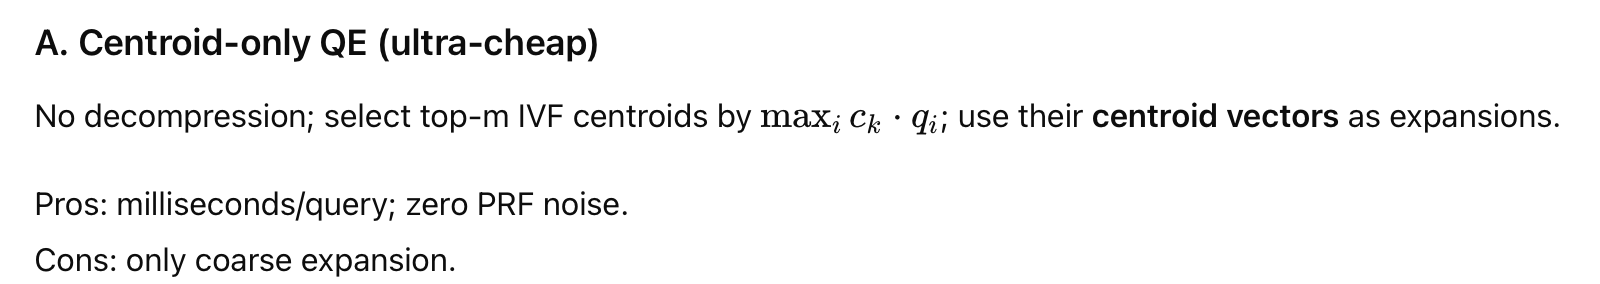

In [16]:
def qe_centroid_only(factory, m=5, beta=0.15):
    import torch, pandas as pd
    from torch.nn.functional import normalize as l2
    C = factory.searcher.ranker.codec.centroids  # [C, dim]

    def _expand(dfq):
        qid, qtext = dfq.iloc[0]["qid"], dfq.iloc[0]["query"]
        Q = factory.searcher.encode([qtext]).squeeze(0).to(torch.float32)
        Q = l2(Q, p=2, dim=-1)
        sims = (C.to(Q.device, Q.dtype) @ Q.T).max(dim=1).values  # [C]
        topc = torch.topk(sims, k=min(m, C.size(0))).indices
        E = l2(C[topc].to(Q.device, Q.dtype), p=2, dim=-1) * beta
        Q_new = torch.cat([Q, E], dim=0).unsqueeze(0)
        return pd.DataFrame([{"qid": qid, "query": qtext, "query_vec": Q_new}])

    import pyterrier as pt
    return pt.apply.by_query(_expand, add_ranks=False)


In [18]:
pipe = qe_centroid_only(factory, m=10, beta=0.2)

plaid_e2e_qe = plaid_end_to_end_qe(factory, k=1000)  # your existing scorer
res2 = pt.Experiment([plaid_e2e_qe,pipe >> plaid_e2e_qe], 
                     topics2019, 
                     qrels2019,
                    eval_metrics=["map","recip_rank","P_10","ndcg_cut_10"], names=["plaid","plaid_qe"],verbose = True)
res2


,name,map,recip_rank,P_10,ndcg_cut_10
0,plaid,0.514464,0.967054,0.834884,0.739252
1,plaid_qe,0.504979,0.963953,0.827907,0.729227


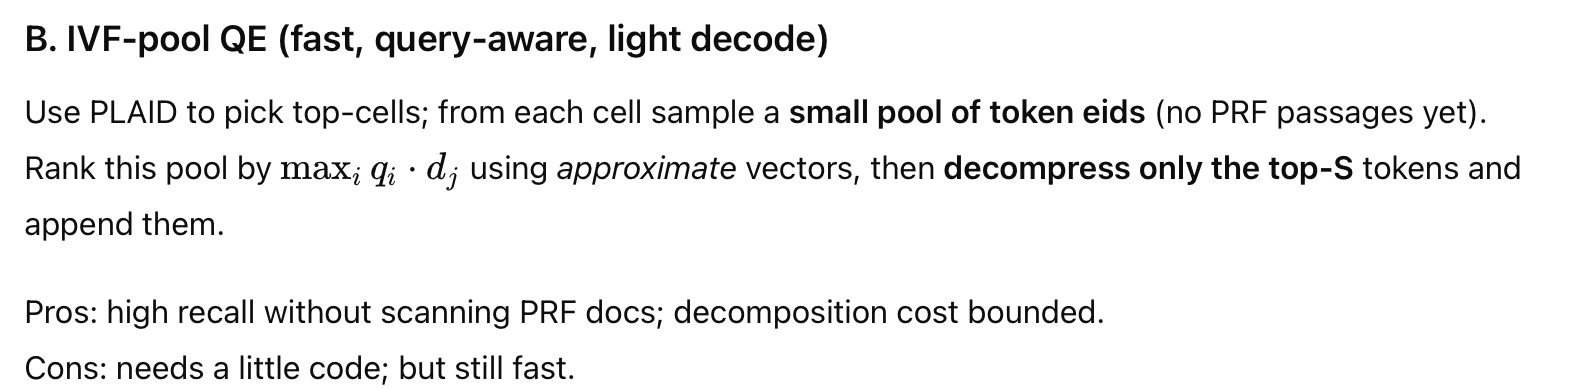

In [19]:
def qe_ivf_pool(factory, ncells=8, per_cell=200, top_exp=12, beta=0.2):
    import numpy as np, pandas as pd, torch
    from torch.nn.functional import normalize as l2

    ranker = factory.searcher.ranker
    codec  = ranker.codec
    ivf    = ranker.ivf
    emb    = ranker.embeddings
    C      = codec.centroids  # [C, dim] (usually CPU)

    def _expand(dfq):
        qid, qtext = dfq.iloc[0]["qid"], dfq.iloc[0]["query"]

        # Query: use its device as the scoring device
        Q = factory.searcher.encode([qtext]).squeeze(0).to(torch.float32)
        device = Q.device
        Q = l2(Q)

        # 1) pick top cells by centroid interaction
        C_dev = C.to(device=device, dtype=Q.dtype)
        cell_sims = (C_dev @ Q.T).max(dim=1).values
        cells = torch.topk(cell_sims, k=min(ncells, C_dev.size(0))).indices.tolist()

        # 2) sample eid’s from those cells (KEEP THEM ON CPU)
        eids_chunks_cpu, C_chunks_dev = [], []
        rng = np.random.default_rng(1234)
        for c in cells:
            packed, lens = ivf.lookup([int(c)])          # may be CPU or CUDA
            L = int(lens[0])
            if L == 0:
                continue
            e = packed[:L].detach()                      # slice
            if e.is_cuda:                                # <<< force CPU
                e = e.cpu()
            if L > per_cell:
                idx = torch.from_numpy(rng.choice(L, size=per_cell, replace=False)).long()  # CPU
                e = e.index_select(0, idx)              # CPU indexing
            eids_chunks_cpu.append(e)                    # CPU LongTensor
            # match sizes with centroids on DEVICE (for coarse scoring only)
            C_chunks_dev.append(C_dev[c].unsqueeze(0).expand(e.shape[0], -1))

        if not eids_chunks_cpu:
            return pd.DataFrame([{"qid": qid, "query": qtext, "query_vec": Q.unsqueeze(0)}])

        eids  = torch.cat(eids_chunks_cpu, dim=0)        # CPU LongTensor [M]
        assert not eids.is_cuda, "eids should be CPU"
        C_pool = torch.cat(C_chunks_dev, dim=0)          # [M, dim] on DEVICE

        # 3) coarse score on DEVICE, then move indices to CPU before indexing eids
        approx = (Q @ C_pool.T).max(dim=0).values        # DEVICE
        S = int(min(top_exp * 5, eids.size(0)))
        top_e = torch.topk(approx, k=S).indices          # DEVICE
        eids_top = eids.index_select(0, top_e.cpu())     # CPU ← CPU

        # 4) decode those eids on CPU, then move decoded vectors to DEVICE
        codes = emb.codes[eids_top]                      # CPU
        res   = emb.residuals[eids_top]                  # CPU
        packed = codec.Embeddings(codes, res)
        V = codec.decompress(packed).to(device=device, dtype=Q.dtype)
        V = l2(V)

        sim = (Q @ V.T).max(dim=0).values                # DEVICE
        k_exp = int(min(top_exp, sim.size(0)))
        top_final = torch.topk(sim, k=k_exp).indices
        E = (beta * V.index_select(0, top_final))

        Q_new = torch.cat([Q, E], dim=0).unsqueeze(0)    # DEVICE
        return pd.DataFrame([{"qid": qid, "query": qtext, "query_vec": Q_new}])

    import pyterrier as pt
    return pt.apply.by_query(_expand, add_ranks=False)


In [21]:
pipe = qe_ivf_pool(factory,ncells=8, per_cell=200, top_exp=12, beta=0.2)

plaid_e2e_qe = plaid_end_to_end_qe(factory, k=1000)  # your existing scorer
res2 = pt.Experiment([plaid_e2e_qe, pipe >> plaid_e2e_qe], topics2019, qrels2019,
                    eval_metrics=["map","recip_rank","P_10","ndcg_cut_10","recall_10","recall_100","recall_1000"], names=["plaid","plaid_qe"])
res2


,name,map,recip_rank,P_10,ndcg_cut_10,recall_10,recall_100,recall_1000
0,plaid,0.514464,0.967054,0.834884,0.739252,0.178544,0.558992,0.690634
1,plaid_qe,0.513339,0.965116,0.832558,0.737210,0.178181,0.558439,0.689497


In [59]:
import numpy as np
def plaid_candidate_generation1(factory) -> pt.Transformer:
    """
    Stage 1: Generate candidates.  For each query, return a single row with
    the encoded query, the list of pids and the centroid_scores.
    Output columns: qid, query, Q, pids, centroid_scores
    """
    # assert plaid_mode == True
    def _generate(df_query):
        assert len(df_query) == 1
        row = df_query.iloc[0]
        qid, query = row.qid, row.query
        Q = factory.searcher.encode([query])

        if 'query_vec' in df_query.columns:
            query_vec = row.query_vec
            # assert query_vec.shape[1]==42
            if isinstance(query_vec, np.ndarray):
                query_vec = torch.from_numpy(query_vec)
            if torch.cuda.is_available():
                query_vec = query_vec.to('cuda', non_blocking=True).to(dtype=torch.float16)
            # print("generating candaite based on expanded query vecs")
            print(query_vec.dim, query_vec.shape)
            pids, centroid_scores = factory.searcher.ranker.generate_candidates(
            factory.searcher.config, query_vec )
            return pd.DataFrame([{
                "qid": qid,
                "query": query,
                "Q_embs": query_vec, # Q_embs is the query embeddings
                # "Exp_embs": query_vec # Exp_embs is the expanded query embeddings
                "pids": pids,
                "score": centroid_scores # centroid_scores before centroid interaction
            }])
        else:
            # print("not")
            pids, centroid_scores = factory.searcher.ranker.generate_candidates(
                factory.searcher.config, Q   )
            return pd.DataFrame([{
                "qid": qid,
                "query": query,
                "Q_embs": Q, # Q_embs is the query embeddings
                "pids": pids,
                "score": centroid_scores # centroid_scores before centroid interaction
            }])
    return pt.apply.by_query(_generate)

In [49]:
def plaid_centroid_interaction1(factory) -> pt.Transformer:
    """
    Stage 2: Compute approximate scores for each candidate.
    Takes the output of candidate_generation and expands it into one row per candidate.
    Output columns: qid, query, pid, docno, approx_score
    """
    # assert self.plaid_mode == True
    def _interact(df):
        rows = []
        for _, r in df.iterrows():
            qid, query = r.qid, r.query
            pids = r.pids
            centroid_scores = r.score #r.score are centroid_scores for centroid interaction
            # lookup token codes for each candidate passage
            # packed_codes: 1D LongTensor，列出该 passage 内所有 token 的 code ID（即 embedding 索引）
            # lengths:      1D LongTensor，告诉你每个 passage（这里只有一个）有多少 tokens
            codes_packed, codes_lengths = factory.searcher.ranker.embeddings_strided.lookup_codes(pids)
            approx_scores_tok = centroid_scores[codes_packed.long()]
            approx_strided = StridedTensor(approx_scores_tok, codes_lengths, use_gpu=False)
            approx_padded, approx_mask = approx_strided.as_padded_tensor()
            approx_scores = colbert_score_reduce(approx_padded, approx_mask, factory.searcher.config)

            for pid, approx in zip(pids.tolist(), approx_scores):
                docno = factory.docnos.fwd[pid]
                # docno = self.docno_mapping.get(pid, "unknown_docno")
                rows.append({
                    "qid": qid,
                    "query": query,
                    "Q_embs": r.Q_embs,
                    "pid": pid,
                    "docno": docno,
                    "score": approx.item() # approx_score after centroid interaction
                })
        return pd.DataFrame(rows)
    return pt.apply.generic(_interact)



In [72]:
ndocs = factory.searcher.config.ndocs
ndocs

1024

In [50]:
def plaid_centroid_pruning1(factory) -> pt.Transformer:
    """
    Stage 3: Prune the approximate scores down to ndocs per query.
    Input columns: qid, query,Q_embs, pid, docno, approx_score
    Output columns: qid, query, pid, docno
    """
    # assert self.plaid_mode == True

    ndocs = factory.searcher.config.ndocs
    def _prune(df):
        pruned_rows = []
        for qid, group in df.groupby("qid"):
            pruned = group.sort_values("score", ascending=False).head(ndocs) # scores are  the approx_scores after centroid interaction
            pruned_rows.append(pruned[["qid", "query", "Q_embs", "pid", "docno"]])
        return pd.concat(pruned_rows).reset_index(drop=True)
    return pt.apply.generic(_prune)

In [51]:
def plaid_final_scoring1(factory, k=1000) -> pt.Transformer:
    """
    Stage 4: Compute full ColBERT scores on the pruned set.
    Input columns: qid, query, pid, docno
    Output columns: qid, docno, score, rank
    """
    # assert self.plaid_mode == True
    def _score(df):
        results = []
        for qid, group in df.groupby("qid"):
            pids = torch.tensor(group["pid"].tolist())
            query = group["query"].iloc[0]
            Q_embs = group["Q_embs"].iloc[0]
            # if isinstance(query_vec, np.ndarray):
            #     Q_embs = torch.from_numpy(group["Q_embs"].iloc[0])
            # if torch.cuda.is_available():
            #     Q_embs = Q_embs.to('cuda', non_blocking=True).to(dtype=torch.float16)

            scores, pids_scored = factory.searcher.ranker.score_pids(
                factory.searcher.config, Q_embs, pids, centroid_scores=None
            )

            # Keep top k results
            topk = min(k, len(scores))
            top_indices = scores.argsort(descending=True)[:topk]
            for rank, idx in enumerate(top_indices):
                pid = pids_scored[idx].item()
                docno = factory.docnos.fwd[pid]
                results.append({
                    "qid": qid,
                    "query": query,
                    "docno": docno,
                    "score": scores[idx].item(),
                    "rank": rank + 1
                })
        return pd.DataFrame(results, columns=["qid","query", "docno", "score", "rank"])

    return pt.apply.by_query(_score)

In [53]:
print("running")
import time
import pandas as pd
start_time = time.time()
exp_Q = qe_before_candidate_generation(factory,top_psg=3,top_exp=10, beta=0.5)(topics.head())
exp_Q
end_time = time.time()

elapsed_time = end_time - start_time
print(f" _prf retrieval time: {elapsed_time:.2f} seconds")
exp_Q

running
 _prf retrieval time: 0.17 seconds


/home1/wangxiao/anaconda3/envs/v2/lib/python3.8/site-packages/colbert/utils/amp.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast() if self.activated else NullContextManager()


,qid,query_vec,query
0,1,[[[[-0.0795 -0.08765 0.1188 0.00936 ...,measurement of dielectric constant of liquids ...
0,2,[[[[-0.1776 -0.04416 0.1089 0.0518 0...,mathematical analysis and design details of wa...
0,3,[[[[ 0.0171 -0.06015 0.02821 0.03723 ...,use of digital computers in the design of band...
0,4,[[[[ 0.09686 -0.0818 0.08014 -0.0602 0...,systems of data coding for information transfer
0,5,[[[[ 0.0692 -0.056 0.04385 -0.0157 -0...,use of programs in engineering testing of comp...


In [88]:
from colbert.search.index_storage import StridedTensor #for plaid stage search
from colbert.modeling.colbert import colbert_score_reduce #for plaid stage search
exp_allstages = (qe_before_candidate_generation(factory,top_psg=3,top_exp=10,beta=0.2)#>>plaid_candidate_generation_explicit(factory)
                 >> plaid_candidate_generation1(factory)
                 # >> plaid_centroid_interaction1(factory)
                 # >> plaid_centroid_pruning1(factory)
                 # >> plaid_final_scoring1(factory,k=1000)
                )
# exp_allstages(topics2019.head(1))

In [184]:
# from colbert.search.index_storage import StridedTensor #for plaid stage search
# from colbert.modeling.colbert import colbert_score_reduce #for plaid stage search
# exp_allstages = (qe_before_candidate_generation(factory,top_psg=3,top_exp=10,beta=0.2)#>>plaid_candidate_generation_explicit(factory)
#                  >> plaid_candidate_generation1(factory)
#                  # >> plaid_centroid_interaction1(factory)
#                  # >> plaid_centroid_pruning1(factory)
#                  # >> plaid_final_scoring1(factory,k=1000)
#                 )
# # exp_allstages(topics2019.head(1))
# res = exp_allstages(topics.head(2))
# res

In [73]:
plaid = (plaid_candidate_generation1(factory)
                 # >> plaid_centroid_interaction1(factory)
                 # >> plaid_centroid_pruning1(factory)
                 # >> plaid_final_scoring1(factory,k=1000)
                )

In [75]:
res = plaid(topics.head())
res

/home1/wangxiao/anaconda3/envs/v2/lib/python3.8/site-packages/colbert/utils/amp.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast() if self.activated else NullContextManager()


,qid,query,Q_embs,pids,score,rank
0,1,measurement of dielectric constant of liquids ...,"[[[tensor(-0.0795, device='cuda:0'), tensor(-0...","[tensor(6, device='cuda:0', dtype=torch.int32)...","[[tensor(0.4224, device='cuda:0', dtype=torch....",0
0,2,mathematical analysis and design details of wa...,"[[[tensor(-0.1777, device='cuda:0'), tensor(-0...","[tensor(1, device='cuda:0', dtype=torch.int32)...","[[tensor(0.4575, device='cuda:0', dtype=torch....",0
0,3,use of digital computers in the design of band...,"[[[tensor(0.0171, device='cuda:0'), tensor(-0....","[tensor(1, device='cuda:0', dtype=torch.int32)...","[[tensor(0.3005, device='cuda:0', dtype=torch....",0
0,4,systems of data coding for information transfer,"[[[tensor(0.0969, device='cuda:0'), tensor(-0....","[tensor(0, device='cuda:0', dtype=torch.int32)...","[[tensor(0.0840, device='cuda:0', dtype=torch....",0
0,5,use of programs in engineering testing of comp...,"[[[tensor(0.0692, device='cuda:0'), tensor(-0....","[tensor(1, device='cuda:0', dtype=torch.int32)...","[[tensor(0.0594, device='cuda:0', dtype=torch....",0


In [185]:
# plaid_centroid_interaction1(factory)(res)

In [64]:
plaid_e2e = factory.plaid_end_to_end()

In [22]:
# Use PyTerrier to evaluate and compare the effectiveness metrics
experiment_results5 = pt.Experiment(
    [plaid_e2e],
    topics2019,
    qrels2019,
    eval_metrics=["map", "recip_rank", "P_10", "ndcg_cut_10", "num_q","mrt"],
    names=[ 'plaid_exp_3_10_0.2'], verbose=True
)

print(experiment_results5)

pt.Experiment: 100%|██████████████████████████| 1/1 [00:02<00:00,  2.30s/system]

                 name       map  recip_rank      P_10  ndcg_cut_10  num_q  \
0  plaid_exp_3_10_0.2  0.514464    0.967054  0.834884     0.739252   43.0   

         mrt  
0  52.660396  


In [66]:
plaid = factory.plaid_candidate_generation() >> factory.plaid_centroid_interaction() >> factory.plaid_centroid_pruning() >> factory.plaid_final_scoring()

In [186]:
# # Use PyTerrier to evaluate and compare the effectiveness metrics
# experiment_results5 = pt.Experiment(
#     [plaid],
#     topics,
#     qrels,
#     eval_metrics=["map", "recip_rank", "P_10", "ndcg_cut_10", "num_q","mrt"],
#     names=[ 'plaid_exp_3_10_0.2'], verbose=True
# )

# print(experiment_results5)

In [187]:
# # Use PyTerrier to evaluate and compare the effectiveness metrics
# experiment_results5 = pt.Experiment(
#     [exp_allstages],
#     topics,
#     qrels,
#     eval_metrics=["map", "recip_rank", "P_10", "ndcg_cut_10", "num_q","mrt"],
#     names=[ 'plaid_exp_3_10_0.2'], verbose=True
# )

# print(experiment_results5)

In [188]:
# # Use PyTerrier to evaluate and compare the effectiveness metrics
# experiment_results5 = pt.Experiment(
#     [exp_allstages,plaid],
#     topics,
#     qrels,
#     eval_metrics=["map", "recip_rank", "P_10", "ndcg_cut_10", "num_q","mrt"],
#     names=[ 'plaid_exp_3_10_0.2','plaid'], verbose=True
# )

# print(experiment_results5)